# Exploration : Remplissage des matchs Paris Basketball

Question métier : quels matchs sous-performent en remplissage, et quels
leviers (tarification, campagnes, timing) pourraient corriger ça ?

Ce notebook explore `gold.fact_match`, construite par le pipeline
(`pipeline/gold/build_gold.py`), qui contient une ligne par match à domicile
avec le taux de remplissage, le contexte sportif, temporel et météo.

In [ ]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

con = duckdb.connect("../data/warehouse/pbb.duckdb")
df = con.execute("SELECT * FROM gold.fact_match ORDER BY date").fetchdf()
print(f"{len(df)} matchs chargés")
df.head()

41 matchs chargés


,match_id,date,heure,competition,journee,adversaire,salle,capacite_salle,billets_vendus,taux_remplissage,revenu_billetterie,prix_moyen_billet,billets_abonnement,billets_unite,part_billets_unite,billets_annules,billets_rembourses,billets_en_attente,taux_annulation,entrees_ok,taux_presence,rang_pbb_avant,rang_adversaire_avant,ecart_classement,score_domicile,score_exterieur,victoire_pbb,jour_semaine,vacances_scolaires,temperature,precipitation
0,M001,2025-10-09,20:45:00,EuroLeague,3,Virtus Bologna,ADIDAS,8000,5173,0.647,327608.62,63.33,2538.0,2164.0,0.418,48,19,137,0.009,4718,0.912,6,17,11,90,79,1,Thursday,False,15.9,0.0
1,M002,2025-10-12,17:00:00,Betclic ÉLITE,3,Monaco,ADIDAS,8000,6746,0.843,378803.40,56.15,2538.0,3446.0,0.511,93,28,132,0.013,6154,0.912,10,4,-6,94,99,0,Sunday,False,17.1,0.0
2,M003,2025-10-15,20:45:00,EuroLeague,4,Kosner Baskonia Vitoria-Gasteiz,ADIDAS,8000,5539,0.692,346957.11,62.64,2538.0,2412.0,0.435,94,49,122,0.016,5085,0.918,4,20,16,105,87,1,Wednesday,False,13.9,0.0
3,M004,2025-10-17,20:45:00,EuroLeague,5,Hapoel Shlomo Tel Aviv,ADIDAS,8000,7577,0.947,536570.44,70.82,2538.0,4200.0,0.554,96,52,195,0.012,6986,0.922,5,10,5,88,89,0,Friday,True,13.2,0.0
4,M005,2025-10-19,14:30:00,Betclic ÉLITE,4,Dijon,ADIDAS,8000,3236,0.405,130772.28,40.41,2538.0,561.0,0.173,8,4,81,0.002,2929,0.905,6,13,7,97,92,1,Sunday,True,13.3,0.0


## 1. Vue d'ensemble du remplissage

In [ ]:
print(df['taux_remplissage'].describe())
print()
print("Par compétition :")
print(df.groupby('competition')['taux_remplissage'].agg(['mean', 'min', 'max', 'count']).round(3))

count    41.000000
mean      0.799683
std       0.124957
min       0.405000
25%       0.747000
50%       0.813000
75%       0.905000
max       0.951000
Name: taux_remplissage, dtype: float64

Par compétition :
                           mean    min    max  count
competition                                         
Betclic ÉLITE             0.746  0.405  0.886     15
Betclic ÉLITE - Playoffs  0.847  0.703  0.935      7
EuroLeague                0.825  0.560  0.951     19


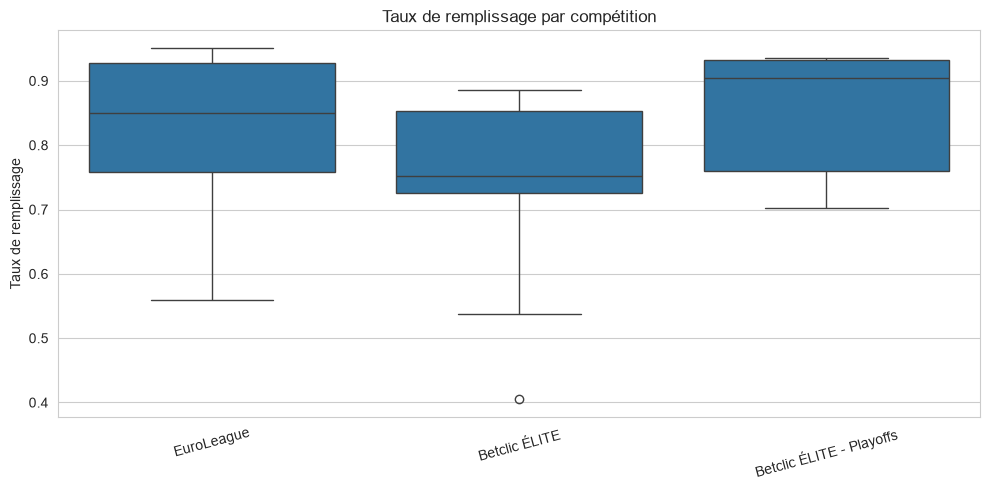

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='competition', y='taux_remplissage', ax=ax)
ax.set_title("Taux de remplissage par compétition")
ax.set_ylabel("Taux de remplissage")
ax.set_xlabel("")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../dashboard/fig_remplissage_par_competition.png", dpi=120)
plt.show()

## 2. Les matchs les plus faibles

Les 8 matchs avec le plus faible taux de remplissage, et leur contexte.

In [ ]:
cols = ['match_id', 'date', 'adversaire', 'competition', 'taux_remplissage',
        'rang_adversaire_avant', 'jour_semaine', 'vacances_scolaires', 'temperature']
df.nsmallest(8, 'taux_remplissage')[cols]

,match_id,date,adversaire,competition,taux_remplissage,rang_adversaire_avant,jour_semaine,vacances_scolaires,temperature
4,M005,2025-10-19,Dijon,Betclic ÉLITE,0.405,13,Sunday,True,13.3
10,M011,2025-12-07,Saint-Quentin,Betclic ÉLITE,0.538,14,Sunday,False,14.4
25,M026,2026-03-12,LDLC ASVEL Villeurbanne,EuroLeague,0.560,20,Thursday,False,10.5
11,M012,2025-12-09,Le Portel,Betclic ÉLITE,0.607,16,Tuesday,False,14.2
0,M001,2025-10-09,Virtus Bologna,EuroLeague,0.647,17,Thursday,False,15.9
2,M003,2025-10-15,Kosner Baskonia Vitoria-Gasteiz,EuroLeague,0.692,20,Wednesday,False,13.9
34,M035,2026-05-26,Strasbourg,Betclic ÉLITE - Playoffs,0.703,22,Tuesday,False,30.8
21,M022,2026-02-01,Boulazac,Betclic ÉLITE,0.711,12,Sunday,False,8.4


## 3. Le classement de l'adversaire a-t-il un effet ?

Hypothèse formée à l'oeil sur les données : un adversaire mal classé
(rang élevé) semble associé à un taux de remplissage plus faible.

In [ ]:
corr = df[['taux_remplissage', 'rang_adversaire_avant', 'rang_pbb_avant', 'ecart_classement']].corr()
print(corr['taux_remplissage'])

taux_remplissage         1.000000
rang_adversaire_avant   -0.625786
rang_pbb_avant           0.330336
ecart_classement        -0.623212
Name: taux_remplissage, dtype: float64


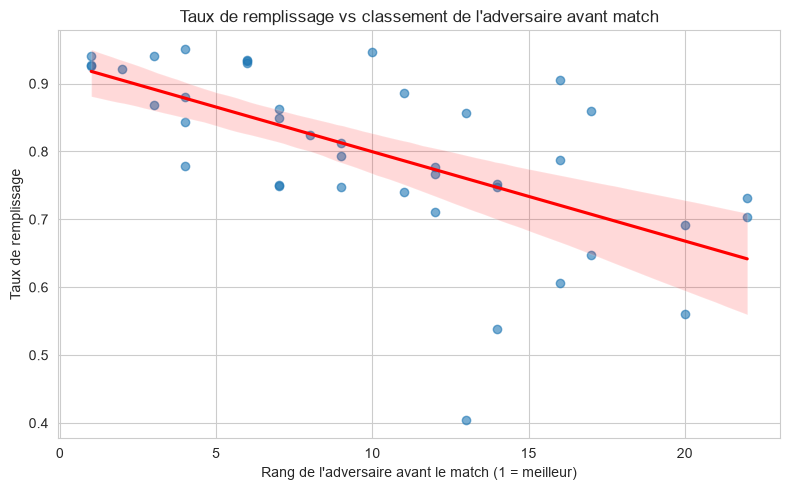

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df, x='rang_adversaire_avant', y='taux_remplissage', ax=ax,
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
ax.set_title("Taux de remplissage vs classement de l'adversaire avant match")
ax.set_xlabel("Rang de l'adversaire avant le match (1 = meilleur)")
ax.set_ylabel("Taux de remplissage")
plt.tight_layout()
plt.savefig("../dashboard/fig_remplissage_vs_classement.png", dpi=120)
plt.show()

## 4. Jour de semaine et vacances scolaires

In [ ]:
print(df.groupby('jour_semaine')['taux_remplissage'].agg(['mean', 'count']).round(3).sort_values('mean'))
print()
print(df.groupby('vacances_scolaires')['taux_remplissage'].agg(['mean', 'count']).round(3))

               mean  count
jour_semaine              
Sunday        0.748     10
Saturday      0.803      5
Thursday      0.810     12
Wednesday     0.813      2
Tuesday       0.819     11
Friday        0.947      1

                     mean  count
vacances_scolaires              
False               0.810     34
True                0.752      7


**Vérification** : l'effet "vacances scolaires" pourrait n'être qu'un
artefact si le calendrier programmait par coïncidence des adversaires plus
faibles pendant les vacances. On vérifie ici que ce n'est pas le cas.

In [ ]:
print(df.groupby('vacances_scolaires')['rang_adversaire_avant'].mean())

vacances_scolaires
False    10.088235
True      9.571429
Name: rang_adversaire_avant, dtype: float64


## 5. Prix moyen du billet vs remplissage

Le prix a-t-il été ajusté à la baisse pour les matchs à faible affluence
anticipée, ou est-ce un effet a posteriori (moins de monde = moins
d'abonnés, qui paient un tarif différent) ?

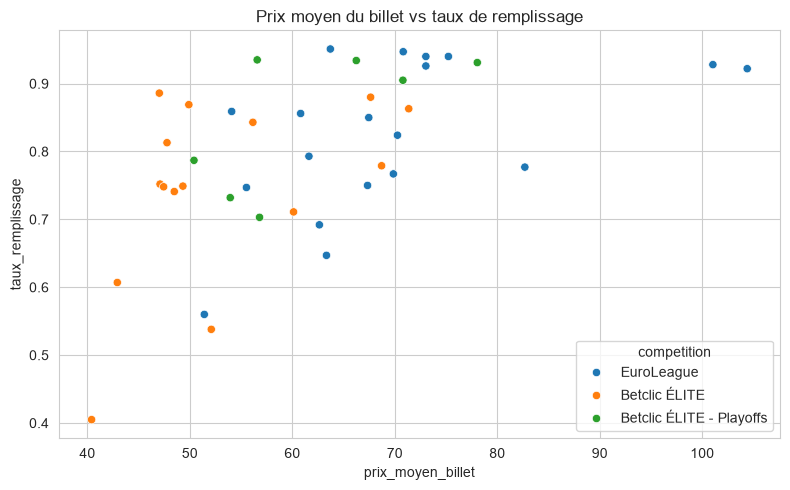

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='prix_moyen_billet', y='taux_remplissage', hue='competition', ax=ax)
ax.set_title("Prix moyen du billet vs taux de remplissage")
plt.tight_layout()
plt.savefig("../dashboard/fig_prix_vs_remplissage.png", dpi=120)
plt.show()

## 6. Effet de la météo

La météo (température, précipitations) a été collectée pour chaque match
mais pas encore explorée. Vérifions si elle influence le remplissage.

In [ ]:
corr_meteo = df[['taux_remplissage', 'temperature', 'precipitation']].corr()
print(corr_meteo['taux_remplissage'])
print()
print("Matchs avec précipitations :", (df['precipitation'] > 0).sum())
print(df.groupby(df['precipitation'] > 0)['taux_remplissage'].agg(['mean', 'count']))

taux_remplissage    1.000000
temperature         0.037348
precipitation       0.024387
Name: taux_remplissage, dtype: float64

Matchs avec précipitations : 9
                   mean  count
precipitation                 
False          0.788188     32
True           0.840556      9


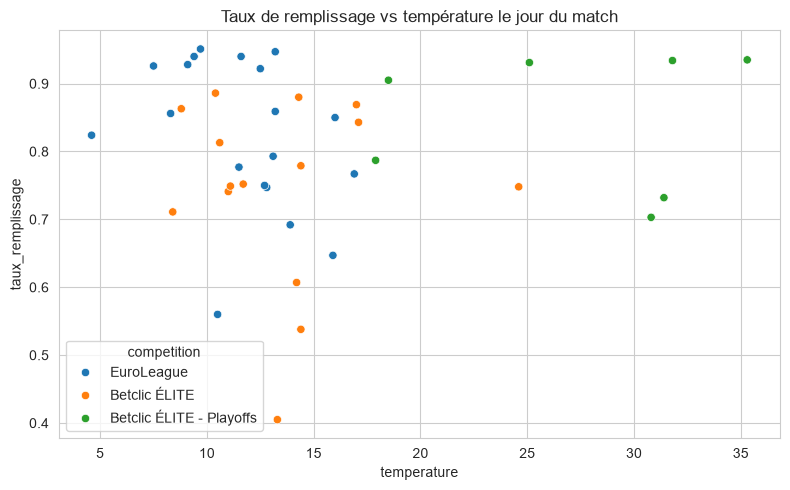

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='temperature', y='taux_remplissage', hue='competition', ax=ax)
ax.set_title("Taux de remplissage vs température le jour du match")
plt.tight_layout()
plt.savefig("../dashboard/fig_meteo_vs_remplissage.png", dpi=120)
plt.show()

## 7. Annulations et remplissage

Utilisation d'une donnée jusqu'ici inexploitée : les commandes annulées
(order_status_id) en billetterie brute, au-delà des seuls billets validés.

In [ ]:
corr_annulation = con.execute("""
    SELECT CORR(taux_remplissage, taux_annulation) AS correlation
    FROM gold.fact_match WHERE taux_annulation IS NOT NULL
""").fetchdf()
print(corr_annulation)
print()
print(df['taux_annulation'].describe())

   correlation
0     0.615886

count    41.000000
mean      0.012122
std       0.003509
min       0.002000
25%       0.010000
50%       0.012000
75%       0.015000
max       0.018000
Name: taux_annulation, dtype: float64


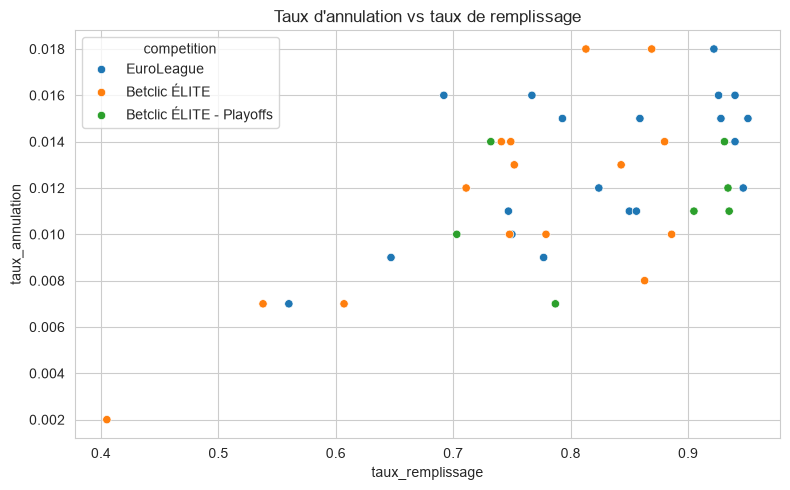

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='taux_remplissage', y='taux_annulation', hue='competition', ax=ax)
ax.set_title("Taux d'annulation vs taux de remplissage")
plt.tight_layout()
plt.savefig("../dashboard/fig_annulation_vs_remplissage.png", dpi=120)
plt.show()

## 8. Satisfaction et remplissage

Croisement de silver.satisfaction (jusqu'ici inutilisée) avec le remplissage.
Un clivage net entre matchs à forte satisfaction (~8+) et faible (~6-6.5)
a été investigué : ni la compétition, ni le type d'enquête, ni la période
de la saison, ni le canal de réponse ne l'expliquent.

**La vraie cause : le résultat du match.** Satisfaction moyenne de 8.14
en victoire contre 6.20 en défaite. Or la victoire est elle-même corrélée
négativement au remplissage (-0.45) : Paris gagne plus souvent quand la
salle est moins remplie, précisément parce que ces matchs sont contre des
adversaires plus faibles (déjà identifié section 3). Remplissage et
satisfaction ne sont donc pas directement liés -- tous deux sont des
conséquences du niveau de l'adversaire.

In [ ]:
df_satisf = con.execute("""
    SELECT f.match_id, f.victoire_pbb, AVG(s.note_globale) AS note_globale_moy, COUNT(*) AS n_reponses
    FROM gold.fact_match f
    JOIN silver.satisfaction s ON f.match_id = s.match_id
    WHERE s.type_enquete = 'POST_MATCH'
    GROUP BY f.match_id, f.victoire_pbb
""").fetchdf()

print(df_satisf.groupby('victoire_pbb')['note_globale_moy'].mean())

victoire_pbb
0    6.194987
1    8.132455
Name: note_globale_moy, dtype: float64


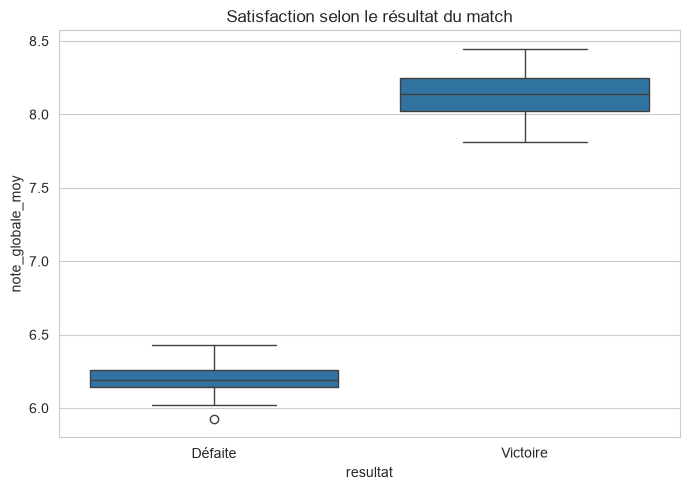

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_satisf.assign(resultat=df_satisf['victoire_pbb'].map({1:'Victoire', 0:'Défaite'})),
            x='resultat', y='note_globale_moy', ax=ax)
ax.set_title("Satisfaction selon le résultat du match")
plt.tight_layout()
plt.savefig("../dashboard/fig_satisfaction_vs_resultat.png", dpi=120)
plt.show()

## 9. L'horaire du match influence-t-il le remplissage ?

Écart apparent net entre après-midi (73.6%) et soirée (81.3%), corrélation
heure/remplissage de 0.26. **Mais confondu avec l'effet jour de semaine** :
5 des 7 matchs d'après-midi sont des dimanches, 2 des samedis -- l'horaire
après-midi est essentiellement une reformulation du calendrier week-end,
pas un facteur indépendant. Pas assez de matchs en semaine à des horaires
non-standards (13h30-17h) pour isoler un vrai effet horaire propre.

**Conclusion : pas de nouveau facteur actionnable ici** -- le levier
pertinent reste le jour de semaine (section 4), pas l'heure en tant que
telle.

In [ ]:
df['heure_minutes'] = df['heure'].apply(lambda t: t.hour * 60 + t.minute)
df['creneau'] = df['heure'].apply(lambda t: 'Après-midi' if t.hour < 18 else 'Soirée')

print(df.groupby('creneau')['taux_remplissage'].agg(['mean', 'count']))
print()
print("Corrélation heure (en minutes) vs remplissage :")
print(df[['taux_remplissage', 'heure_minutes']].corr().iloc[0,1])

                mean  count
creneau                    
Après-midi  0.736143      7
Soirée      0.812765     34

Corrélation heure (en minutes) vs remplissage :
0.26345785139988276


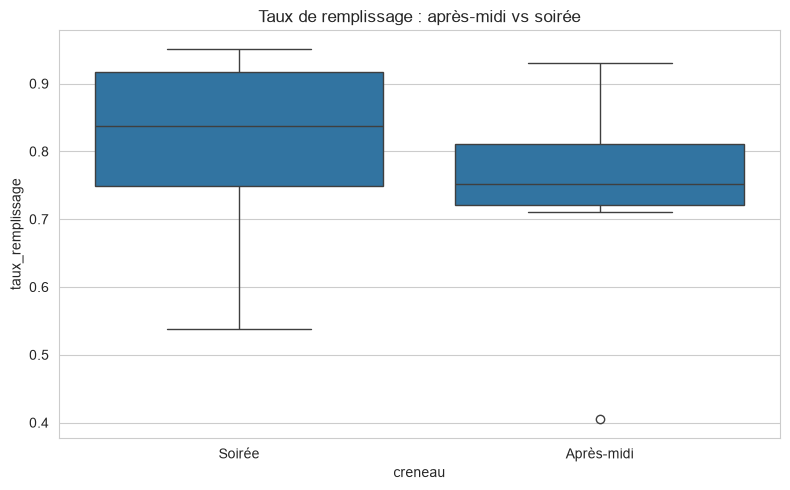

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='creneau', y='taux_remplissage', ax=ax)
ax.set_title("Taux de remplissage : après-midi vs soirée")
plt.tight_layout()
plt.savefig("../dashboard/fig_remplissage_par_creneau.png", dpi=120)
plt.show()

In [ ]:
print(pd.crosstab(df['creneau'], df['jour_semaine']))

jour_semaine  Friday  Saturday  Sunday  Thursday  Tuesday  Wednesday
creneau                                                             
Après-midi         0         2       5         0        0          0
Soirée             1         3       5        12       11          2


## 10. Bassin de fans par densité démographique

Croisement de silver.contacts (code_postal) avec les données de population
(population/communes_idf, population/arrondissements_paris) : d'où viennent
réellement les fans, rapporté à la population de leur zone -- pas juste en
volume brut.

**Limite** : 25 codes postaux sur 69 dans `silver.contacts` n'ont pas de
correspondance dans les référentiels de population (probablement des fans
hors Île-de-France, ou des codes postaux fictifs issus des données de test).
L'analyse porte donc sur le bassin francilien uniquement.

In [ ]:
pop_par_cp = con.execute("""
    WITH pop_brute AS (
        SELECT UNNEST(codesPostaux) AS code_postal, population
        FROM bronze.raw_population_arrondissements
        UNION ALL
        SELECT UNNEST(codesPostaux) AS code_postal, population
        FROM bronze.raw_population_communes
        WHERE nom != 'Paris'
    )
    SELECT code_postal, SUM(population) AS population
    FROM pop_brute
    GROUP BY code_postal
""").fetchdf()

contacts_par_cp = con.execute("""
    SELECT code_postal, COUNT(*) AS nb_contacts
    FROM silver.contacts WHERE code_postal IS NOT NULL
    GROUP BY code_postal
""").fetchdf()

bassin = contacts_par_cp.merge(pop_par_cp, on='code_postal', how='left')
bassin['contacts_pour_1000_hab'] = (bassin['nb_contacts'] * 1000 / bassin['population']).round(2)
bassin = bassin.dropna(subset=['population']).sort_values('contacts_pour_1000_hab', ascending=False)

print(f"{bassin['code_postal'].nunique()} codes postaux avec population connue")
print(f"{contacts_par_cp.shape[0] - bassin.shape[0]} codes postaux non matchés (hors IDF ou codes invalides)")
bassin.head(15)

44 codes postaux avec population connue
25 codes postaux non matchés (hors IDF ou codes invalides)


,code_postal,nb_contacts,population,contacts_pour_1000_hab
1,75018,12479,183127.0,68.14
54,78300,2657,40983.0,64.83
57,75019,11223,178691.0,62.81
34,93400,3154,53615.0,58.83
22,78100,2693,45931.0,58.63
32,77400,2601,48262.0,53.89
48,94800,3200,60183.0,53.17
40,93500,3201,61929.0,51.69
25,94200,3334,65064.0,51.24
28,91300,2644,51729.0,51.11


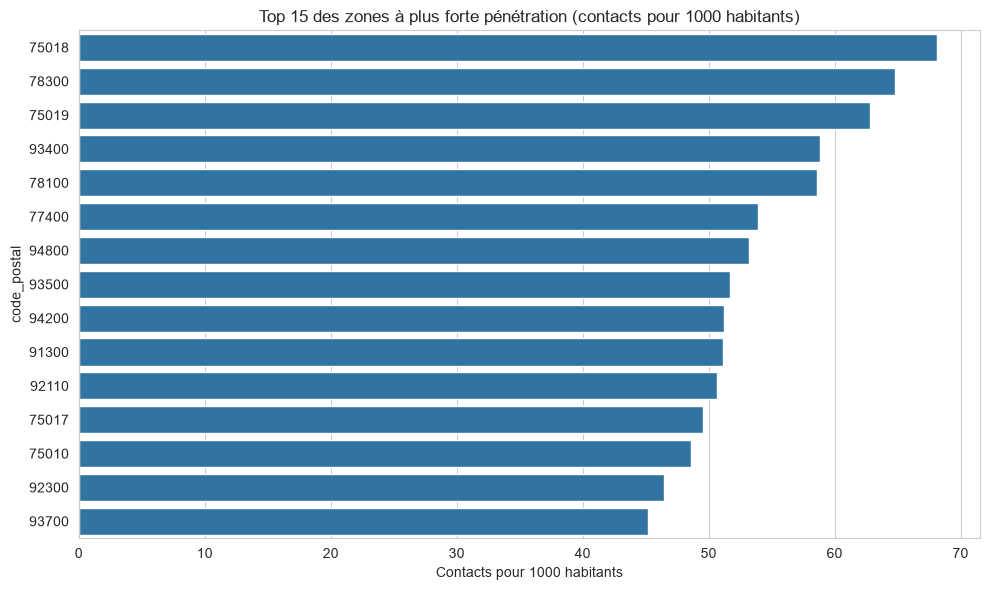

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
top15 = bassin.head(15)
sns.barplot(data=top15, y='code_postal', x='contacts_pour_1000_hab', ax=ax, orient='h',
            order=top15['code_postal'].astype(str))
ax.set_title("Top 15 des zones à plus forte pénétration (contacts pour 1000 habitants)")
ax.set_xlabel("Contacts pour 1000 habitants")
plt.tight_layout()
plt.savefig("../dashboard/fig_bassin_fans.png", dpi=120)
plt.show()

## 11. Modèle de prédiction du taux de remplissage

Régression Ridge (régularisée, adaptée à un petit échantillon) sur les features déjà disponibles en gold : classement de l'adversaire, compétition, jour de semaine, vacances scolaires. Validation croisée leave-one-out (LOO), adaptée aux 41 observations disponibles -- un split train/test classique gaspillerait trop de données de test.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.preprocessing import StandardScaler

features = pd.get_dummies(
    df[['rang_adversaire_avant', 'competition', 'jour_semaine', 'vacances_scolaires']],
    columns=['competition', 'jour_semaine'], drop_first=True
)
X = features.values.astype(float)
y = df['taux_remplissage'].values.astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = Ridge(alpha=1.0)
loo = LeaveOneOut()
mae_scores = -cross_val_score(model, X_scaled, y, cv=loo, scoring='neg_mean_absolute_error')
print(f"MAE moyen (LOO-CV) : {mae_scores.mean():.3f}")
print(f"Remplissage moyen observé : {y.mean():.3f}")
print(f"Erreur relative : {mae_scores.mean()/y.mean()*100:.1f}%")

MAE moyen (LOO-CV) : 0.067
Remplissage moyen observé : 0.800
Erreur relative : 8.3%


rang_adversaire_avant                  -0.086475
competition_Betclic ÉLITE - Playoffs    0.056512
jour_semaine_Thursday                  -0.050933
jour_semaine_Tuesday                   -0.049266
jour_semaine_Sunday                    -0.046259
competition_EuroLeague                  0.041894
jour_semaine_Wednesday                 -0.022084
vacances_scolaires                     -0.021484
jour_semaine_Saturday                  -0.016761
dtype: float64


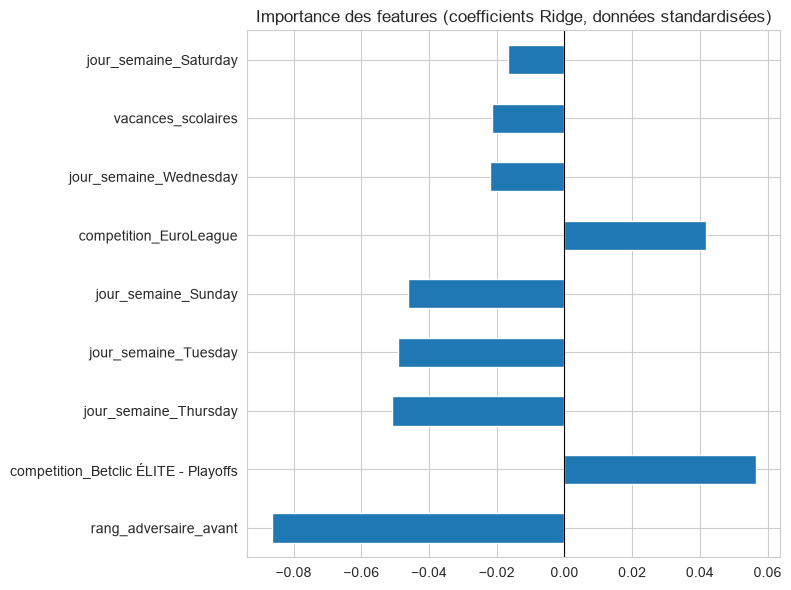

In [ ]:
model.fit(X_scaled, y)
importance = pd.Series(model.coef_, index=features.columns).sort_values(key=abs, ascending=False)
print(importance)

fig, ax = plt.subplots(figsize=(8, 6))
importance.plot(kind='barh', ax=ax)
ax.set_title("Importance des features (coefficients Ridge, données standardisées)")
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig("../dashboard/fig_modele_importance.png", dpi=120)
plt.show()

**Résultat** : MAE de 8.3% (erreur relative) en validation croisée
leave-one-out : solide pour 41 observations. Le modèle confirme
statistiquement que `rang_adversaire_avant` est de loin la feature la
plus influente, cohérent avec l'analyse descriptive (section 3). Les
coefficients par jour de semaine sont à interpréter avec prudence : ils
sont relatifs à un jour de référence (vendredi) qui n'apparaît qu'une
seule fois dans le dataset, donc peu fiable comme base de comparaison.

**Limite du modèle** : avec 41 observations, ce modèle sert surtout à
confirmer et quantifier les facteurs déjà identifiés par l'analyse
descriptive, pas à faire des prédictions fiables sur de nouveaux matchs
hors de cette saison.

## 12. Funnel e-commerce et performance des campagnes

Exploitation de web_sessions et web_evenements (GA4), jusqu'ici chargées
mais jamais analysées -- suivi du parcours d'achat sur la boutique en
ligne, et efficacité des campagnes email/SMS.

In [ ]:
funnel = con.execute("""
    SELECT
        COUNT(DISTINCT session_id) FILTER (WHERE event_name = 'view_item_list') AS vue_liste,
        COUNT(DISTINCT session_id) FILTER (WHERE event_name = 'add_to_cart') AS panier,
        COUNT(DISTINCT session_id) FILTER (WHERE event_name = 'begin_checkout') AS checkout,
        COUNT(DISTINCT session_id) FILTER (WHERE event_name = 'purchase') AS achat
    FROM silver.web_evenements
""").fetchdf()
print("Funnel (sessions distinctes) :")
print(funnel)
print(f"\nTaux panier -> achat : {funnel['achat'][0] / funnel['panier'][0] * 100:.1f}%")

Funnel (sessions distinctes) :
   vue_liste  panier  checkout  achat
0     116222   72907     51937  39382

Taux panier -> achat : 54.0%


In [ ]:
conversion_source = con.execute("""
    SELECT source, medium, COUNT(*) AS sessions, 
           ROUND(COUNT(*) FILTER (WHERE revenue > 0) * 100.0 / COUNT(*), 2) AS taux_conversion_pct
    FROM silver.web_sessions
    GROUP BY source, medium
    HAVING COUNT(*) > 1000
    ORDER BY taux_conversion_pct DESC
""").fetchdf()
print("\nConversion par canal d'acquisition :")
print(conversion_source)


Conversion par canal d'acquisition :
           source    medium  sessions  taux_conversion_pct
0             sms       sms     12498                22.60
1      newsletter     email     37335                22.47
2          google       cpc     21257                22.30
3        facebook    social     18315                 7.13
4        (direct)    (none)     78697                 7.02
5          google   organic    128800                 6.99
6       instagram    social     43969                 6.90
7          tiktok    social     14696                 6.74
8  euroleague.net  referral      7115                 6.58
9               x    social     11113                 6.54


In [ ]:
campagnes = con.execute("""
    SELECT canal,
            COUNT(*) FILTER (WHERE evenement='DELIVRE') AS delivres,
            ROUND(COUNT(*) FILTER (WHERE evenement='OUVERTURE') * 100.0 / NULLIF(COUNT(*) FILTER (WHERE evenement='DELIVRE'),0), 1) AS taux_ouverture_pct,
            ROUND(COUNT(*) FILTER (WHERE evenement='CLIC') * 100.0 / NULLIF(COUNT(*) FILTER (WHERE evenement='OUVERTURE'),0), 1) AS taux_clic_pct
    FROM bronze.raw_campagnes_evenements
    GROUP BY canal
""").fetchdf()
print(campagnes)

   canal  delivres  taux_ouverture_pct  taux_clic_pct
0  EMAIL    672808                21.3           22.6
1    SMS    137549                38.4           34.5


   canal  delivres  taux_ouverture_pct  taux_clic_pct
0    SMS    137549                38.4           34.5
1  EMAIL    672808                21.3           22.6


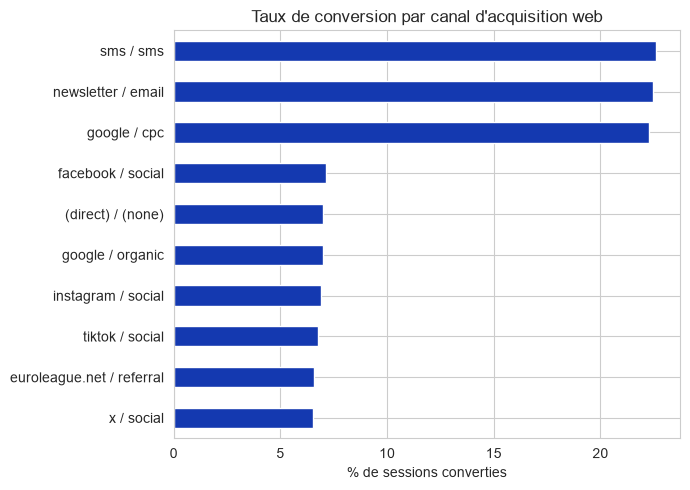

In [ ]:
conversion_source['canal_label'] = conversion_source['source'] + ' / ' + conversion_source['medium']

fig, ax = plt.subplots(figsize=(7, 5))
conversion_source.sort_values('taux_conversion_pct').plot(
    kind='barh', x='canal_label', y='taux_conversion_pct', ax=ax, legend=False, color='#1439B0'
)
ax.set_title("Taux de conversion par canal d'acquisition web")
ax.set_xlabel("% de sessions converties")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../dashboard/fig_conversion_par_canal.png", dpi=120)
plt.show()

**Résultats** : les canaux propriétaires (SMS, newsletter, Google Ads
payant) convertissent 3x mieux (~22.5%) que l'organique et le social
(~6.5-7%), même si ces derniers génèrent bien plus de volume de trafic
(78 697 sessions en direct et 128 800 en organique, contre ~12 000-37 000
pour les canaux propriétaires). Le SMS surperforme l'email en engagement
(38.4% d'ouverture, 34.5% de clic, contre 21.3%/22.6% pour l'email) tout
en convertissant aussi bien que la newsletter (22.6%).

**Recommandation actionnable** : prioriser le SMS pour les campagnes à
fort enjeu (matchs à faible remplissage anticipé, cf. section 3), et
concentrer le budget d'acquisition payante sur les canaux à forte
conversion plutôt que sur l'élargissement de l'audience
organique/sociale déjà large mais peu convertissante.

## 13. Synthèse

Le classement de l'adversaire domine largement les autres facteurs. Sur les 41 matchs de la saison, le taux de remplissage passe d'environ 90% face à un adversaire du haut du tableau à environ 65% face à un adversaire mal classé, et le modèle de régression confirme que cette variable pèse plus que toutes les autres réunies.

Les compétitions ne se valent pas non plus : Playoffs (84.7%) et EuroLeague (82.5%) remplissent mieux que le championnat national Betclic ÉLITE (74.6%). Le dimanche reste le jour le plus faible (74.8% sur 10 matchs, contre 81-82% les mardis et jeudis), et les vacances scolaires réduisent aussi le remplissage (75.2% contre 81% hors vacances), un résultat contre-intuitif que j'ai vérifié avant de le retenir : le rang moyen des adversaires est comparable dans les deux groupes (9.6 contre 10.1), donc l'écart ne vient pas d'un calendrier qui placerait des adversaires plus faibles pendant les vacances.

Deux hypothèses raisonnables n'ont, elles, rien donné. La météo n'a aucun effet mesurable (corrélations de 0.04 pour la température, 0.02 pour les précipitations). L'horaire du match non plus, une fois isolé du jour de semaine : 71% des matchs d'après-midi tombent un dimanche, donc l'écart apparent entre après-midi et soirée n'était qu'une reformulation d'un effet déjà identifié.

Les annulations augmentent avec la demande (corrélation de 0.62) : les matchs les plus attendus génèrent proportionnellement plus d'achats annulés ensuite, même si l'ampleur reste faible en absolu (0.2% à 1.8% du volume). Et la satisfaction du public suit le résultat sportif, pas le remplissage : 8.14/10 en victoire contre 6.20/10 en défaite. Une première corrélation entre remplissage et satisfaction (-0.38) laissait croire à un lien direct, mais il s'agit en fait de deux conséquences distinctes du même facteur, puisque la victoire elle-même est corrélée à -0.45 avec le remplissage.

Côté géographie, les 18e et 19e arrondissements affichent la plus forte pénétration de fans rapportée à la population (68 et 63 contacts pour 1000 habitants), cohérent avec la proximité de l'Adidas Arena. Plusieurs communes de petite couronne (Poissy, Saint-Ouen, Villejuif) ressortent aussi bien.

Le modèle de régression (Ridge, validation croisée leave-one-out) obtient une erreur moyenne de 8.3%, solide pour 41 observations, et confirme statistiquement que le classement adversaire domine.

Enfin, côté digital, les canaux propriétaires (SMS, newsletter, Google Ads payant) convertissent trois fois mieux (~22.5%) que l'organique et le social (~6.5-7%), et le SMS surperforme l'email en engagement (38.4% d'ouverture contre 21.3%) tout en convertissant aussi bien que la newsletter.

### Recommandations

1. **Tarification dynamique par force d'adversaire.** Une politique plus agressive sur les matchs contre des adversaires classés au-delà de la 15e place.
2. **Campagnes ciblées sur les dimanches et les vacances scolaires**, en priorisant le SMS pour son meilleur engagement.
3. **Capitaliser sur l'EuroLeague** dans la communication et le packaging des abonnements, vu l'écart de 8 points avec le championnat.
4. **Adapter la politique d'annulation** sur les matchs premium : frais modulés ou liste d'attente pour récupérer les places libérées tardivement.
5. **Renforcer le marketing géolocalisé** dans le nord-est parisien, et cibler l'acquisition dans les zones à fort potentiel démographique mais faible pénétration actuelle.
6. **Réallouer le budget d'acquisition payante** vers les canaux qui convertissent le mieux plutôt que vers l'organique.

### Limites

L'échantillon reste petit : 41 matchs, avec parfois un seul match par catégorie, donc certains découpages sont à prendre avec prudence. Le modèle sert surtout à confirmer et chiffrer ce que l'analyse descriptive montrait déjà, pas à prédire des matchs hors de cette saison.

L'effet horaire et l'effet météo ont été testés puis écartés ; je les garde dans ce notebook pour montrer la démarche complète, pas seulement les résultats qui confirment quelque chose. L'analyse de satisfaction ne porte que sur les réponses POST_MATCH, l'analyse géographique se limite au bassin francilien, et le funnel digital concerne la boutique en ligne, pas la billetterie.

Côté qualité de données, le pipeline a rencontré et corrigé plusieurs anomalies réelles (fichiers JSON corrompus, fichier scan sans en-tête, fichier scan vide, formats de date multiples), détaillées dans `docs/data_quality.md`.